In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
img_size = (128, 128)
batch_size = 32
dataset_path = "cell_images"

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.


In [4]:
class_names = train_ds.class_names
print(class_names)

['Parasitized', 'Uninfected']


In [5]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [8]:
model = keras.Sequential([

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

C:\Users\manan lad\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 294s 369ms/step - accuracy: 0.7364 - loss: 0.5018 - val_accuracy: 0.9376 - val_loss: 0.1613
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 282s 408ms/step - accuracy: 0.9363 - loss: 0.1914 - val_accuracy: 0.9521 - val_loss: 0.1444
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 284s 412ms/step - accuracy: 0.9483 - loss: 0.1632 - val_accuracy: 0.9523 - val_loss: 0.1384
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 237s 344ms/step - accuracy: 0.9545 - loss: 0.1454 - val_accuracy: 0.9541 - val_loss: 0.1392
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 200s 290ms/step - accuracy: 0.9559 - loss: 0.1416 - val_accuracy: 0.9557 - val_loss: 0.1283
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 192s 278ms/step - accuracy: 0.9579 - loss: 0.1311 - val_accuracy: 0.9584 - val_loss: 0.1248
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 196s 284ms/step - accuracy: 0.9555 - loss: 0.1431 - val_accuracy: 0.9526 - val_loss: 0.1416
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 195s 283ms/step - accuracy: 0.9566 -

In [11]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

173/173 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.9553 - loss: 0.1345
Validation Accuracy: 0.9579023718833923


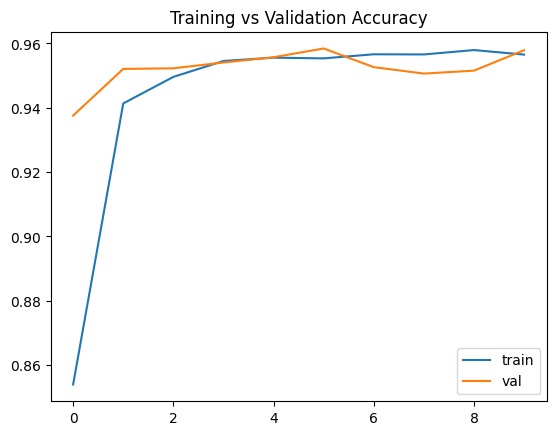

In [12]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(acc)
plt.plot(val_acc)

plt.title("Training vs Validation Accuracy")
plt.legend(["train","val"])

plt.show()